This notebook tests the functionality of Acoustic_2D_Cart_Grid.py and PT_model.py by performing forward and ajoint simulations

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from time import time
import PT_model
from PT_model import Acoustic_2D_Cartesian_Grid
import PT_data_classes
from copy import copy

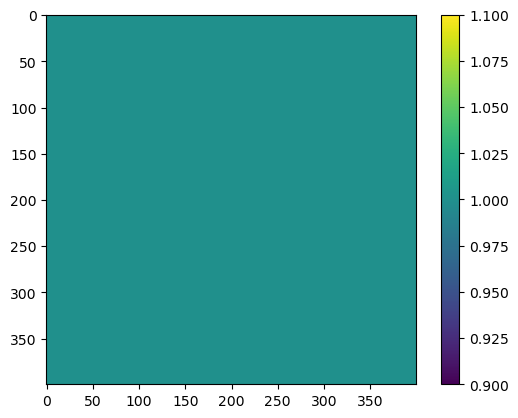

In [2]:

# set model parameters
h = 0.1
Nx = 400
Nz = 400
c = np.ones((Nz, Nx), dtype=np.float32)
ABC_sides = [1, 3, 4]
stacey_ABCs = True
sponge_ABCs = False
sponge_alpha = 0.25
sponge_pnts = 100

model_params = PT_data_classes.Acoustic_2D_Grid_model_params(h=h,
                                                             Nx=Nx,
                                                             Nz=Nz,
                                                             c=c,
                                                             ABC_sides=ABC_sides,
                                                             stacey_ABCs=stacey_ABCs,
                                                             sponge_ABCs=sponge_ABCs,
                                                             sponge_alpha=sponge_alpha,
                                                             sponge_pnts=sponge_pnts)

# initialize instace of the model class
model = Acoustic_2D_Cartesian_Grid(model_params=model_params)

plt.imshow(model.model_params.c)
plt.colorbar()


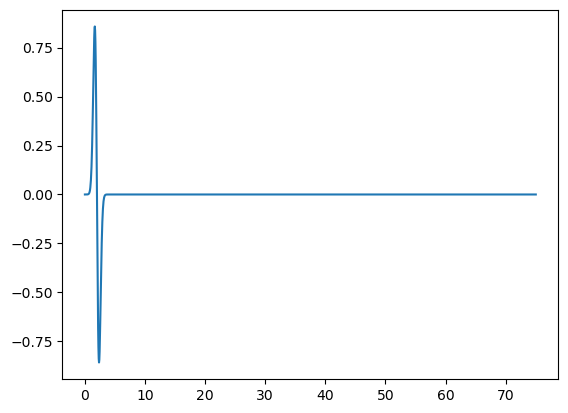

In [3]:
# set time parameters
T_max = 75
delta_t = 0.05
Nt: int = int(T_max / delta_t) + 1
t = np.arange(Nt) * delta_t

# create first derivative of a gaussian STF
STFS = np.zeros((Nt, 1))
f_0 = 0.5
t_0 = 1/f_0
stf = -8. * (t - t_0) * f_0 * (np.exp(-1.0 * (4*f_0) ** 2 * (t - t_0) ** 2))

plt.plot(t, stf)
STFS[:, 0] = stf

In [4]:
# create locations of sources
source_inds = []
source_inds.append((200, 150))

# create locations of receivers
rec_inds = []
rec_inds.append((200, 250))

# initioalize aquisition parameters
aquisition_params = PT_data_classes.Aquisition_params(Nt=Nt,
                                                      delta_t=delta_t,
                                                      STFS=STFS,
                                                      source_inds=source_inds,
                                                      rec_inds=rec_inds)

# create save indice
save_inds = np.arange(0, Nt+1).tolist()
save_inds = save_inds[::5]      # decimate save_inds list

In [5]:
# call the forward solver

start = time()

u_out, SG = model.forward(aquisition_params=aquisition_params,
                    save_inds=save_inds)[0:2]
end = time()

print(end-start)

1.095729112625122


In [6]:
plt_inds = [
    1 * (len(save_inds) // 4),
    2 * (len(save_inds) // 4),
    3 * (len(save_inds) // 4),
    4 * (len(save_inds) // 4)
]

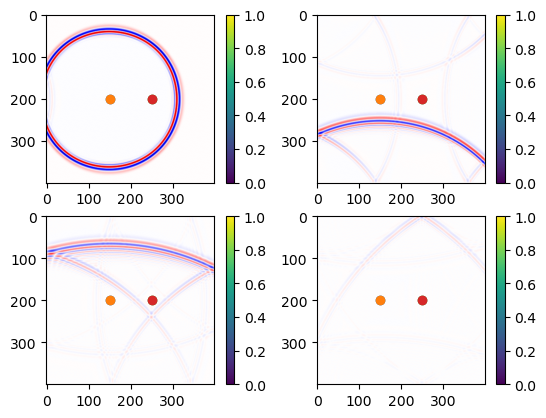

In [7]:

for i in range(len(plt_inds)): 
	plt_ind = plt_inds[i]
	plt.subplot(2, 2, i+1)
	plt.imshow(u_out[plt_ind], vmax=1*np.max(u_out[100]),vmin=-1*np.max(u_out[100]), cmap="seismic")
	plt.scatter(source_inds[0][1], source_inds[0][0])
	plt.scatter(source_inds[-1][1], source_inds[-1][0])
	plt.scatter(rec_inds[0][1], rec_inds[0][0])
	plt.scatter(rec_inds[-1][1], rec_inds[-1][0])
	plt.colorbar()



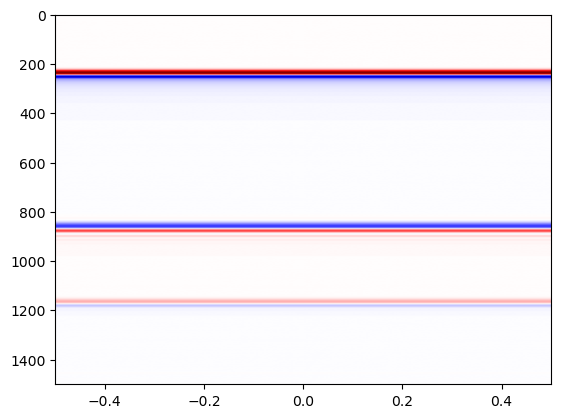

In [8]:
# plot shot gather
# SG[600:, :] = 0.0
plt.imshow(SG, aspect="auto", cmap="seismic", vmax=1*np.max(np.abs(SG)), vmin=-1*np.max(np.abs(SG)))

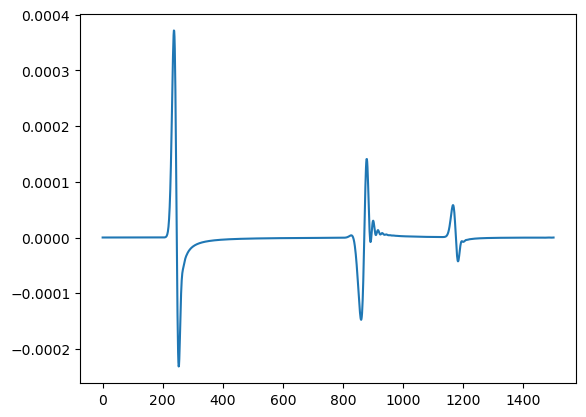

In [9]:
plt.plot(SG)

In [10]:
# initialize adjoint aquisition parameters
adj_STFS = np.flip(SG - np.roll(SG, -10, axis=0), axis=0)

adj_aquisition_params = copy(aquisition_params)
adj_aquisition_params.STFS = adj_STFS
adj_aquisition_params.source_inds = rec_inds

# call the adjoint solver
start = time()
adj_out, adj_SG, SK, HK = model.adjoint(aquisition_params=adj_aquisition_params,
                    save_inds=save_inds,
                    u_prev=None,
                    u=None,
                    wave_fields=u_out,
                    compute_hessian_kernel=True,
                    save_adjoint_wavefield=True)
end = time()

print(end-start)

0.8328554630279541


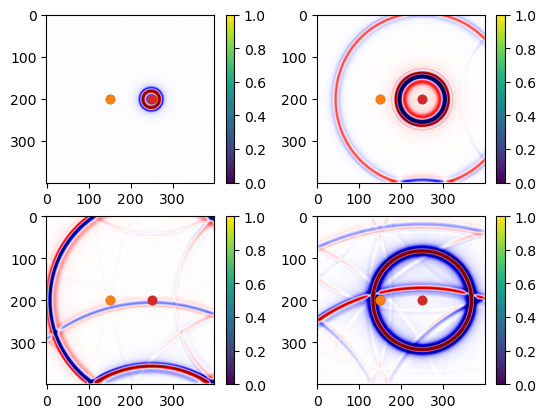

In [11]:

for i in range(len(plt_inds)): 
	plt_ind = plt_inds[i]
	plt.subplot(2, 2, i+1)
	plt.imshow(adj_out[plt_ind], vmax=1*np.max(adj_out[160]),vmin=-1*np.max(adj_out[160]), cmap="seismic")
	plt.scatter(source_inds[0][1], source_inds[0][0])
	plt.scatter(source_inds[0][1], source_inds[-1][0])
	plt.scatter(rec_inds[0][1], rec_inds[0][0])
	plt.scatter(rec_inds[0][1], rec_inds[-1][0])
	plt.colorbar()

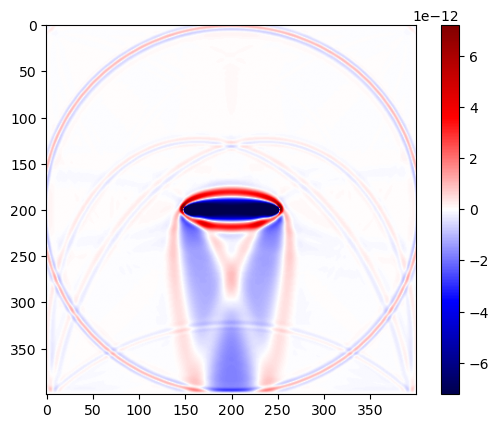

In [12]:
# plot the sensitivity kernel
plt.imshow(SK, cmap="seismic", vmax=0.1*np.max(np.abs(SK)), vmin=-0.1*np.max(np.abs(SK)))
plt.colorbar()

/tmp/ipykernel_3814818/1244829843.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(HK), cmap="turbo")


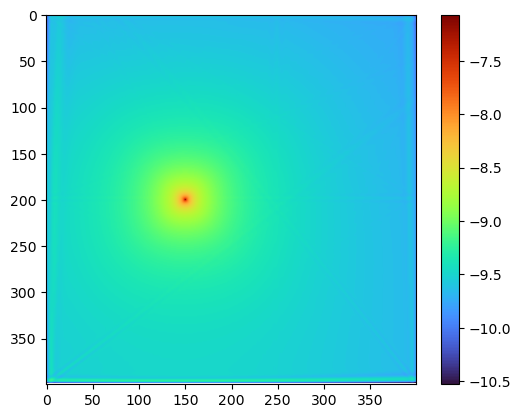

In [13]:

plt.imshow(np.log10(HK), cmap="turbo")
plt.colorbar()

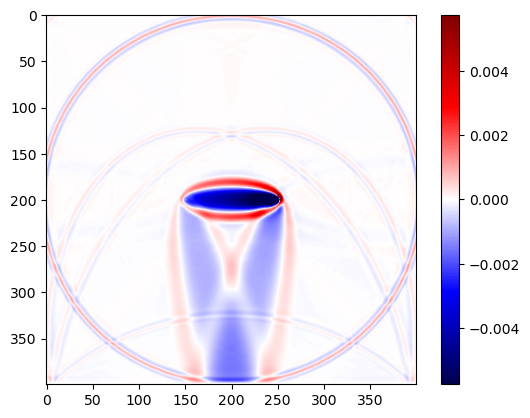

In [14]:
G = SK / (HK + 0.01*np.max(np.abs(HK)))
plt.imshow(G, cmap="seismic", vmin=-0.1*np.max(np.abs(G)), vmax=0.1*np.max(np.abs(G)))
plt.colorbar()